# Evaluate Fine-Tuned BERT Model

This notebook evaluates the performance of the fine-tuned BERT model on the test dataset. It includes metrics calculation and visualization of results.

In [1]:
import os
import sys
from pathlib import Path

# Add src directory to python path:
src_path = str(Path(os.getcwd()).parent / "src")

if src_path not in sys.path:
    sys.path.append(src_path)

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
from tqdm.auto import tqdm

# Configure plotting style:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

/Users/7312/Desktop/Repositories/phishing-transformer-detection/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration:
MODEL_PATH = "../saved_models/fine_tuned_bert"
DATA_PATH = "../data/split/test.csv"
TEXT_COL = "Text"
LABEL_COL = "Is_Phishing"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if torch.backends.mps.is_available():
    DEVICE = "mps"
    
print(f"Using device: {DEVICE}")

Using device: mps


## 1. Load Test Data

In [3]:
def load_test_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Test data not found at {path}")
    
    df = pd.read_csv(path)
    X = df[TEXT_COL].astype(str).tolist()
    y = df[LABEL_COL].map({False: 0, True: 1}).astype(int) if df[LABEL_COL].dtype == bool else df[LABEL_COL].astype(int)
    
    return X, y

X_test, y_test = load_test_data(DATA_PATH)

print(f"Loaded {len(X_test)} test samples")
print(f"Class distribution:\n{y_test.value_counts(normalize=True)}")

Loaded 1693 test samples
Class distribution:
Is_Phishing
1    0.555818
0    0.444182
Name: proportion, dtype: float64


## 2. Load Fine-Tuned Model

In [4]:
print(f"Loading model from {MODEL_PATH}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.to(DEVICE)
model.eval()

pipe = pipeline("text-classification", model=model, tokenizer=tokenizer, device=DEVICE, truncation=True, max_length=512, top_k=None)

Loading model from ../saved_models/fine_tuned_bert...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2378.41it/s, Materializing param=classifier.weight]                                      


## 3. Make Predictions

In [5]:
print("Running inference...")

predictions = pipe(X_test, batch_size=16)

y_prob = []
y_pred = []

for pred in predictions:
    score_map = {item['label']: item['score'] for item in pred}
    
    # Check if labels are named 'LABEL_0', 'LABEL_1' or something else...
    pos_label = 'LABEL_1' if 'LABEL_1' in score_map else '1'
    neg_label = 'LABEL_0' if 'LABEL_0' in score_map else '0'
    
    prob_pos = score_map.get(pos_label, 0.0)
    y_prob.append(prob_pos)
    y_pred.append(1 if prob_pos >= 0.5 else 0)

y_prob = np.array(y_prob)
y_pred = np.array(y_pred)

Running inference...


## 4. Evaluation Metrics

Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98       752
    Phishing       0.97      0.99      0.98       941

    accuracy                           0.98      1693
   macro avg       0.98      0.98      0.98      1693
weighted avg       0.98      0.98      0.98      1693



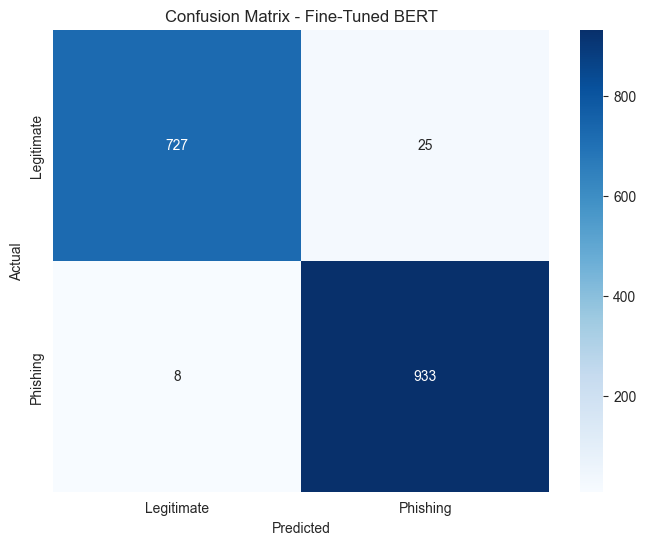

In [6]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

# Confusion Matrix:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Fine-Tuned BERT')
plt.show()

## 5. ROC Curve

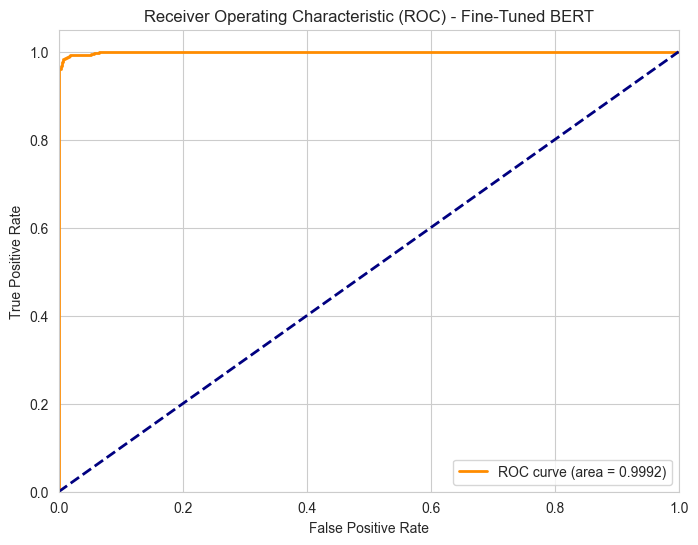

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Fine-Tuned BERT')
plt.legend(loc="lower right")
plt.show()

## 6. Precision-Recall Curve

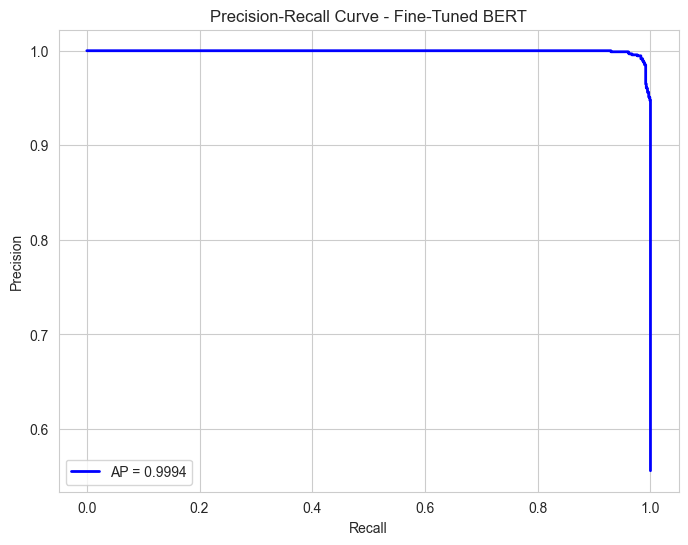

In [8]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
average_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'AP = {average_precision:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Fine-Tuned BERT')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

## 7. Confidence Distribution

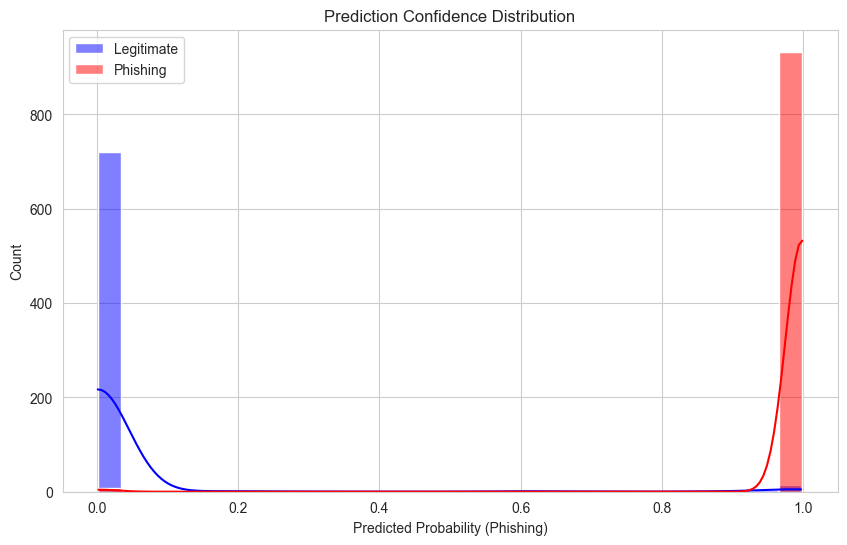

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(y_prob[y_test == 0], color='blue', label='Legitimate', kde=True, bins=30, alpha=0.5)
sns.histplot(y_prob[y_test == 1], color='red', label='Phishing', kde=True, bins=30, alpha=0.5)
plt.xlabel('Predicted Probability (Phishing)')
plt.ylabel('Count')
plt.title('Prediction Confidence Distribution')
plt.legend()
plt.show()